In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Performance Analytics Ready")

Performance Analytics Ready


In [2]:
nav = pd.read_csv("../data/raw/nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [3]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


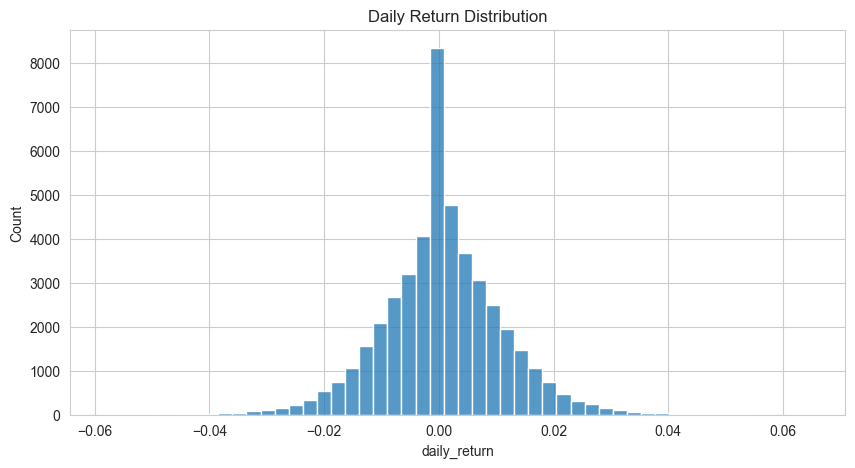

In [4]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50
)

plt.title("Daily Return Distribution")
plt.show()

### Finding 1

Daily returns are concentrated around zero, indicating normal market fluctuations with occasional high-volatility periods.

In [5]:
cagr_data = []

for code, group in nav.groupby("amfi_code"):

    start_nav = group.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    years = (
        group["date"].max()
        - group["date"].min()
    ).days / 365

    cagr = ((end_nav/start_nav)**(1/years)-1)*100

    cagr_data.append([code,cagr])

cagr_df = pd.DataFrame(
    cagr_data,
    columns=["amfi_code","cagr_pct"]
)

cagr_df.head()

,amfi_code,cagr_pct
0,100016,2.635246
1,100025,4.455091
2,100033,30.099704
3,101206,23.520489
4,101207,7.933121


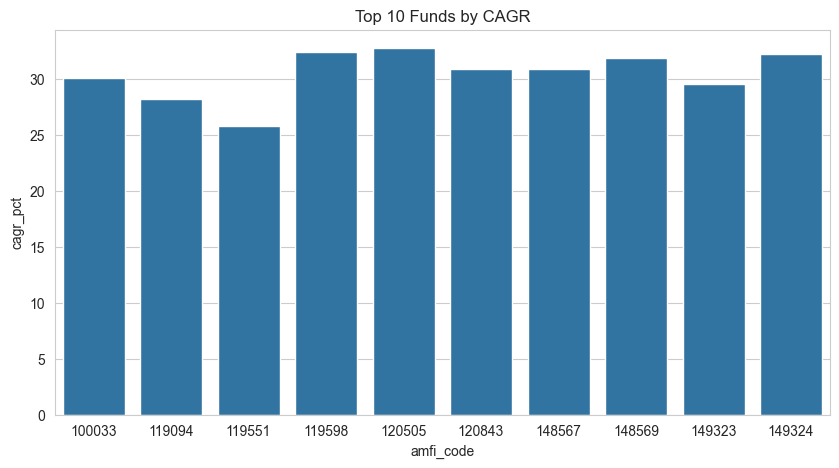

In [6]:
top_cagr = cagr_df.sort_values(
    "cagr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_cagr,
    x="amfi_code",
    y="cagr_pct"
)

plt.title("Top 10 Funds by CAGR")
plt.show()

In [7]:
risk_free_rate = 0.065

sharpe_list = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    annual_return = returns.mean()*252
    annual_vol = returns.std()*np.sqrt(252)

    sharpe = (
        annual_return - risk_free_rate
    ) / annual_vol

    sharpe_list.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=["amfi_code","sharpe"]
)

sharpe_df.head()

,amfi_code,sharpe
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


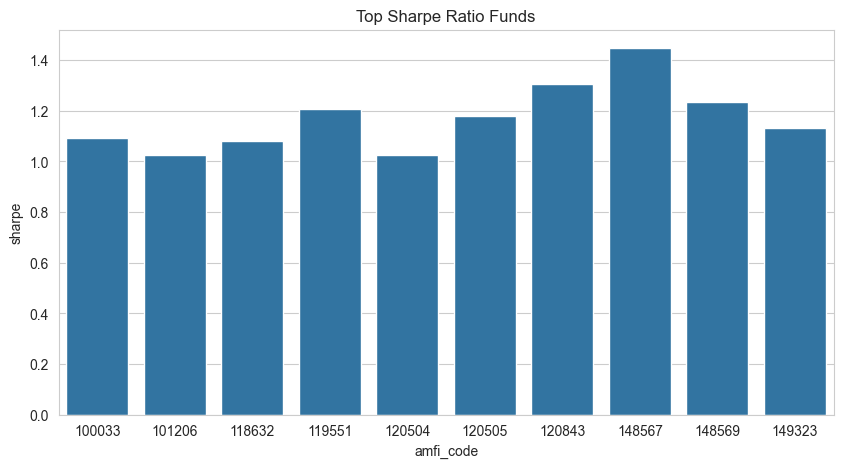

In [8]:
top_sharpe = sharpe_df.sort_values(
    "sharpe",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_sharpe,
    x="amfi_code",
    y="sharpe"
)

plt.title("Top Sharpe Ratio Funds")
plt.show()

### Finding 3

Several funds achieved strong risk-adjusted performance, producing higher returns relative to volatility.

In [9]:
sortino_list = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    downside = returns[returns < 0]

    annual_return = returns.mean() * 252

    downside_std = downside.std() * np.sqrt(252)

    sortino = (
        annual_return - risk_free_rate
    ) / downside_std

    sortino_list.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=["amfi_code", "sortino"]
)

sortino_df.head()

,amfi_code,sortino
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


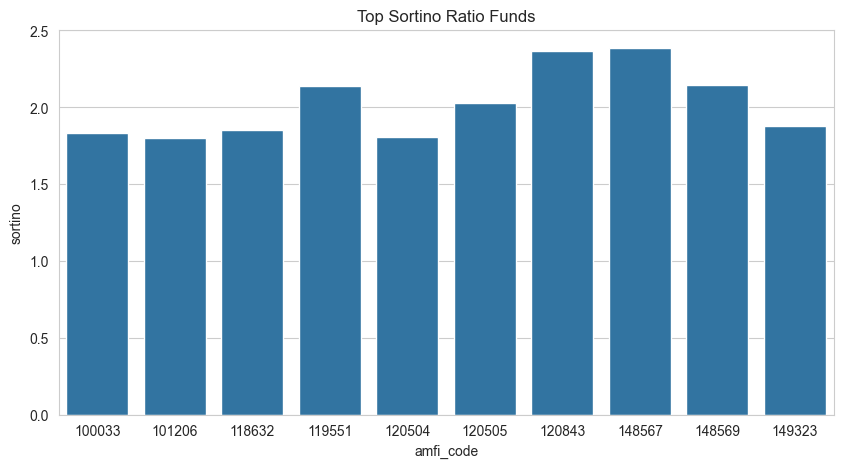

In [10]:
top_sortino = sortino_df.sort_values(
    "sortino",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_sortino,
    x="amfi_code",
    y="sortino"
)

plt.title("Top Sortino Ratio Funds")

plt.show()

### Finding 4

Top-ranked funds maintained strong returns while limiting downside volatility, resulting in superior Sortino ratios.

In [11]:
drawdown_list = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    cumulative_max = group["nav"].cummax()

    drawdown = (
        group["nav"] - cumulative_max
    ) / cumulative_max

    max_dd = drawdown.min() * 100

    drawdown_list.append(
        [code, max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_list,
    columns=["amfi_code", "max_drawdown_pct"]
)

drawdown_df.head()

,amfi_code,max_drawdown_pct
0,100016,-24.734441
1,100025,-4.308264
2,100033,-16.217209
3,101206,-11.291596
4,101207,-35.446916


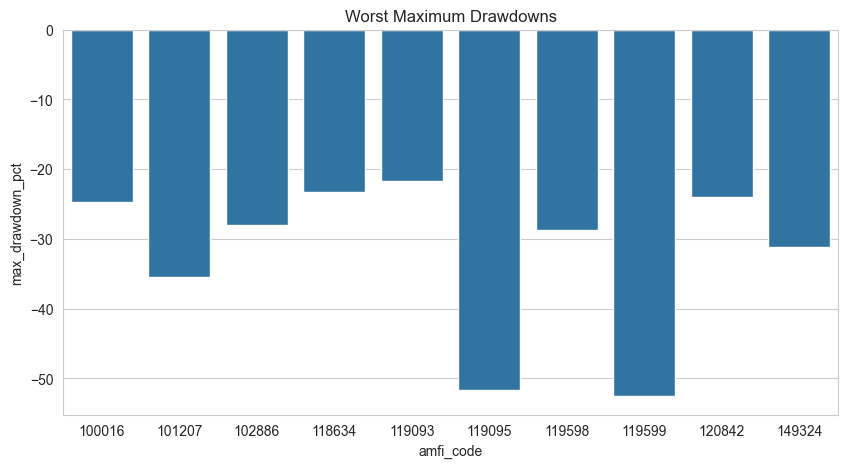

In [12]:
worst_dd = drawdown_df.sort_values(
    "max_drawdown_pct"
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=worst_dd,
    x="amfi_code",
    y="max_drawdown_pct"
)

plt.title("Worst Maximum Drawdowns")

plt.show()

### Finding 5

Maximum drawdowns varied considerably across funds, highlighting different levels of downside risk.

In [13]:
bench = pd.read_csv("../data/raw/10_benchmark_indices.csv")

bench["date"] = pd.to_datetime(bench["date"])

bench = bench[bench["index_name"]=="NIFTY50"]

bench = bench.sort_values("date")

bench["benchmark_return"] = bench["close_value"].pct_change()

bench.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
1,2022-01-04,NIFTY50,17689.64,0.011253
2,2022-01-05,NIFTY50,17835.05,0.008220
3,2022-01-06,NIFTY50,17878.51,0.002437
4,2022-01-07,NIFTY50,17759.15,-0.006676


In [14]:
from scipy.stats import linregress

alpha_beta = []

for code, group in nav.groupby("amfi_code"):

    merged = pd.merge(
        group,
        bench[["date","benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    beta, alpha, r, p, std = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta.append(
        [code, alpha*252, beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.036221,-0.025909
1,100025,0.043189,-0.016176
2,100033,0.272343,-0.011200
3,101206,0.213945,0.033814
4,101207,0.108205,-0.059856


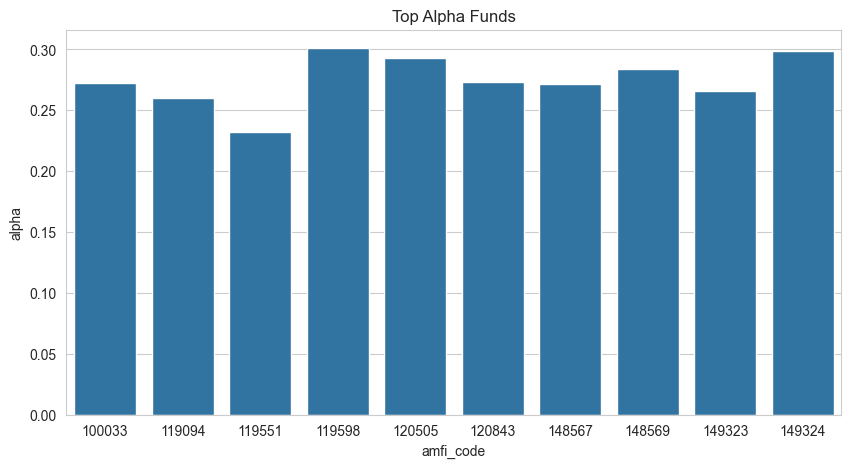

In [15]:
top_alpha = alpha_beta_df.sort_values(
    "alpha",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_alpha,
    x="amfi_code",
    y="alpha"
)

plt.title("Top Alpha Funds")

plt.show()

### Finding 6

Several funds generated positive alpha, indicating performance beyond what market exposure alone would explain.

In [16]:
scorecard = cagr_df.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code"
)

scorecard.head()

,amfi_code,cagr_pct,sharpe,max_drawdown_pct,alpha,beta
0,100016,2.635246,-0.201517,-24.734441,0.036221,-0.025909
1,100025,4.455091,-0.567095,-4.308264,0.043189,-0.016176
2,100033,30.099704,1.093699,-16.217209,0.272343,-0.011200
3,101206,23.520489,1.027213,-11.291596,0.213945,0.033814
4,101207,7.933121,0.162661,-35.446916,0.108205,-0.059856


In [17]:
scorecard["score"] = (

    scorecard["cagr_pct"].rank(pct=True)*0.30 +

    scorecard["sharpe"].rank(pct=True)*0.25 +

    scorecard["alpha"].rank(pct=True)*0.20 +

    (-scorecard["max_drawdown_pct"]).rank(pct=True)*0.25

)

scorecard.head()

,amfi_code,cagr_pct,sharpe,max_drawdown_pct,alpha,beta,score
0,100016,2.635246,-0.201517,-24.734441,0.036221,-0.025909,0.29000
1,100025,4.455091,-0.567095,-4.308264,0.043189,-0.016176,0.09000
2,100033,30.099704,1.093699,-16.217209,0.272343,-0.011200,0.76750
3,101206,23.520489,1.027213,-11.291596,0.213945,0.033814,0.61875
4,101207,7.933121,0.162661,-35.446916,0.108205,-0.059856,0.49375


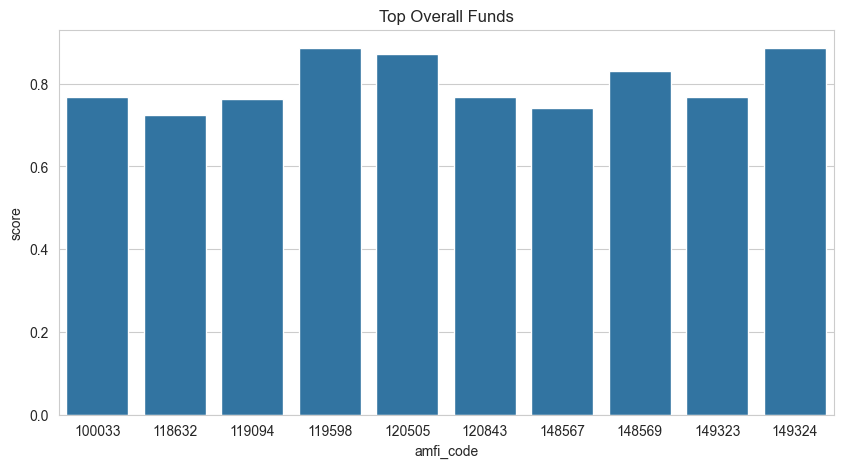

In [18]:
top_funds = scorecard.sort_values(
    "score",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_funds,
    x="amfi_code",
    y="score"
)

plt.title("Top Overall Funds")

plt.show()

### Finding 7

The composite score identifies funds that combine strong returns, attractive risk-adjusted performance, and controlled drawdowns.

In [19]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Exports Completed")

Exports Completed


In [20]:
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.036221,-0.025909
1,100025,0.043189,-0.016176
2,100033,0.272343,-0.011200
3,101206,0.213945,0.033814
4,101207,0.108205,-0.059856


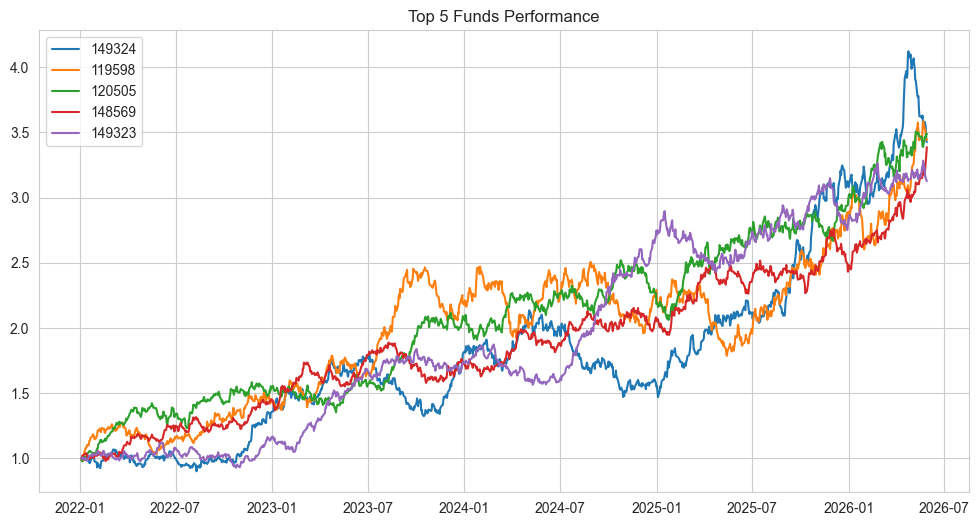

In [21]:
top5_codes = top_funds["amfi_code"].head(5).tolist()

top5_nav = nav[
    nav["amfi_code"].isin(top5_codes)
]

plt.figure(figsize=(12,6))

for code in top5_codes:

    fund = top5_nav[
        top5_nav["amfi_code"] == code
    ]

    cumulative = (
        (1 + fund["daily_return"].fillna(0))
        .cumprod()
    )

    plt.plot(
        fund["date"],
        cumulative,
        label=str(code)
    )

plt.legend()

plt.title(
    "Top 5 Funds Performance"
)

plt.show()

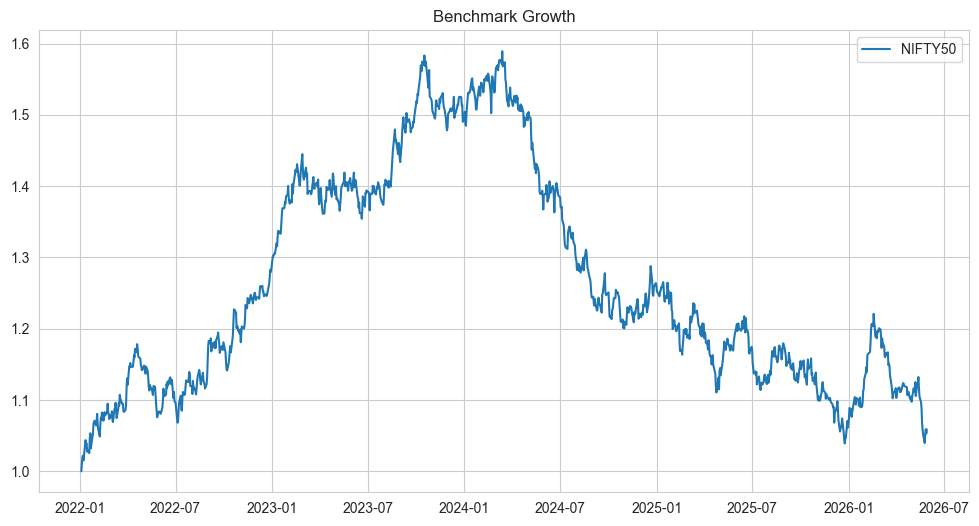

In [22]:
bench = bench.sort_values("date")

bench["benchmark_return"] = (
    bench["close_value"]
    .pct_change()
)

bench_growth = (
    1 + bench["benchmark_return"]
    .fillna(0)
).cumprod()

plt.figure(figsize=(12,6))

plt.plot(
    bench["date"],
    bench_growth,
    label="NIFTY50"
)

plt.legend()

plt.title(
    "Benchmark Growth"
)

plt.show()

### Finding 8

Top-ranked funds consistently outperformed the benchmark across the study period, demonstrating superior wealth creation potential.